In [3]:
# Install gymnasium
%pip install swig
%pip install "gymnasium[box2d]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp311-cp311-linux_x86_64.whl size=2379415 sha256=4953da37aa754845bfdb8ca7811455177f1d5692d080f3a1fced90fc656e03ba
  Stored in directory: /root/.cache/pip/wheels/ab/f1/0c/d56f4a2bdd12bae0a0693ec33f2f0daadb5eb9753c78fa5308
Successfully built box2d-py


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import gymnasium as gym
import matplotlib.pyplot as plt
import imageio
from collections import deque
from IPython.display import HTML
from matplotlib import animation

In [5]:
def get_device():
    """
    Returns the available computing device (CUDA if available, otherwise CPU).

    Returns:
        torch.device: The device object ('cuda' or 'cpu').
    """
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Feedforward Neural Network for DQN

This is a simple **feedforward neural network** that:
- Takes a *state* as input
- Outputs a *vector of Q-values* for each possible action

### Neural Network Architecture:

- **Input** (size = 8)  
  ↓  
- **fc1** → Hidden Layer 1 (128 units)  
  ↓  
- **fc2** → Hidden Layer 2 (128 units)  
  ↓  
- **fc3** → Output Layer (4 actions)

Output:
- The output dimension is equal to the number of actions i.e. 4 for LunarLander.

In [6]:
class QNetwork(nn.Module):
    """
    A simple feedforward neural network for approximating Q-values in reinforcement learning.

    Args:
        state_size (int): Dimension of each state input.
        action_size (int): Dimension of each action output.

    Attributes:
        fc1 (nn.Linear): First fully connected layer.
        fc2 (nn.Linear): Second fully connected layer.
        fc3 (nn.Linear): Output layer mapping to action values.
    """
    def __init__(self, state_size, action_size):
        super().__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_size)

    def forward(self, state):
        """
        Defines the forward pass through the network.

        Args:
            state (torch.Tensor): The input tensor representing the environment state.

        Returns:
            torch.Tensor: The output tensor representing Q-values for each action.
        """
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

## DQNAgent

This class implements a **Deep Q-Network (DQN) agent** used in reinforcement learning. It interacts with an environment to learn optimal actions using experience replay and target network stabilization.

### Key Features

- **Experience Replay**: Stores past experiences to train more effectively.
- **Target Network**: Improves learning stability with a slowly-updated Q-network.
- **Epsilon-Greedy Strategy**: Balances exploration and exploitation.
- **Soft Updates**: Gradually updates the target network towards the local network.

This agent can be integrated easily with OpenAI Gym environments for training and evaluation.


In [ ]:
class DQNAgent:
    def __init__(self,
                 state_size,
                 action_size,
                 lr=1e-3,
                 gamma=0.99,
                 tau=1e-3,
                 initial_epsilon=1.0,
                 final_epsilon=0.01,
                 epsilon_decay=0.995,
                 temperature=1.0,
                 strategy='epsilon-greedy'):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=100_000)
        self.batch_size = 64
        self.gamma = gamma
        self.tau = tau
        self.epsilon = initial_epsilon
        self.final_epsilon = final_epsilon
        self.epsilon_decay = epsilon_decay
        self.temperature = temperature
        self.strategy = strategy.lower()  # 'epsilon-greedy', 'boltzmann', 'greedy'

        self.device = get_device()
        self.qnetwork_local = QNetwork(state_size, action_size).to(self.device)
        self.qnetwork_target = QNetwork(state_size, action_size).to(self.device)
        self.optimizer = optim.Adam(self.qnetwork_local.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def act(self, state):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.qnetwork_local(state_tensor).squeeze()

        if self.strategy == 'epsilon-greedy':
            if random.random() < self.epsilon:
                return random.randint(0, self.action_size - 1)
            return int(torch.argmax(q_values))

        elif self.strategy == 'boltzmann':
            probs = torch.softmax(q_values / self.temperature, dim=0).cpu().numpy()
            return int(np.random.choice(np.arange(self.action_size), p=probs))

        elif self.strategy == 'greedy':
            return int(torch.argmax(q_values))

        else:
            raise ValueError(f"Unknown strategy '{self.strategy}'")

    def step(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def learn(self):
        experiences = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*experiences)

        states = torch.FloatTensor(np.array(states)).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        Q_targets_next = self.qnetwork_target(next_states).detach().max(1)[0].unsqueeze(1)
        Q_targets = rewards + (self.gamma * Q_targets_next * (1 - dones))
        Q_expected = self.qnetwork_local(states).gather(1, actions)

        loss = self.loss_fn(Q_expected, Q_targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self._soft_update()

        return loss.item()

    def _soft_update(self):
        for target_param, local_param in zip(self.qnetwork_target.parameters(),
                                             self.qnetwork_local.parameters()):
            target_param.data.copy_(self.tau * local_param.data +
                                    (1.0 - self.tau) * target_param.data)

    def decay_exploration(self):
        if self.strategy == 'epsilon-greedy':
            self.epsilon = max(self.final_epsilon, self.epsilon * self.epsilon_decay)
            return self.epsilon
        elif self.strategy == 'boltzmann':
            self.temperature = max(0.1, self.temperature * 0.995)
            return self.temperature

## DQN Training Loop for LunarLander-v3

This block trains a `DQNAgent` on the `LunarLander-v3` environment using OpenAI Gym.

In [ ]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")
# agent = DQNAgent(state_size=8, action_size=4)
agent_eps = DQNAgent(state_size=8, action_size=4, strategy='epsilon-greedy')
agent_boltz = DQNAgent(state_size=8, action_size=4, strategy='boltzmann')
agents = [agent_eps, agent_boltz]
strategies = ['epsilon-greeedy', 'botzmann']

n_episodes = 1000
best_reward = 200

episode_rewards = {}
episode_losses = {}
episode_parameters = {}

for agent, strategy in zip(agents, strategies):
    parameter = agent.epsilon if strategy == 'epsilon-greedy' else agent.temperature
    for i_episode in range(1, n_episodes + 1):
        state, _ = env.reset()
        total_reward = 0
        losses = []
        done = False

        while not done:
            action = agent.act(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.step(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

            if len(agent.memory) > agent.batch_size:
                loss = agent.learn()
                losses.append(loss)


        episode_rewards.get(strategy,[]).append(total_reward)
        episode_losses.get(strategy, []).append(np.mean(losses) if losses else 0)
        episode_parameters.get(strategy, []).append(parameter)

        print(f"Episode {i_episode}: Reward = {total_reward:.2f},"
            f"Loss = {np.mean(losses):.4f}, Epsilon = {parameter:.3f}")

        parameter = agent.decay_exploration()

Episode 1: Reward = -74.71,Loss = 163.0295, Epsilon = 1.000
Episode 2: Reward = -135.53,Loss = 91.7794, Epsilon = 0.995
Episode 3: Reward = 20.56,Loss = 96.2903, Epsilon = 0.990
Episode 4: Reward = -146.48,Loss = 123.8592, Epsilon = 0.985
Episode 5: Reward = -67.63,Loss = 117.7266, Epsilon = 0.980
Episode 6: Reward = -58.80,Loss = 92.0385, Epsilon = 0.975
Episode 7: Reward = -306.40,Loss = 64.8181, Epsilon = 0.970
Episode 8: Reward = -162.45,Loss = 66.1407, Epsilon = 0.966
Episode 9: Reward = -131.31,Loss = 38.8598, Epsilon = 0.961
Episode 10: Reward = -323.88,Loss = 39.4230, Epsilon = 0.956
Episode 11: Reward = -80.64,Loss = 54.9019, Epsilon = 0.951
Episode 12: Reward = -52.35,Loss = 48.4036, Epsilon = 0.946
Episode 13: Reward = -352.35,Loss = 59.6773, Epsilon = 0.942
Episode 14: Reward = -244.47,Loss = 73.0922, Epsilon = 0.937
Episode 15: Reward = -122.18,Loss = 72.6022, Epsilon = 0.932
Episode 16: Reward = -400.60,Loss = 55.8326, Epsilon = 0.928
Episode 17: Reward = -129.04,Loss = 6

In [9]:
def record_episode(agent, env, filename):
    """
    Save an agent's behavior as a GIF by running a single episode.

    Args:
        agent (DQNAgent): The trained agent to evaluate.
        env (gym.Env): The environment to interact with.
    """
    frames = []
    state, _ = env.reset()
    done = False
    while not done:
        frame = env.render()
        frames.append(frame)
        action = agent.act(state)
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
    env.close()
    imageio.mimsave(filename, frames, fps=30)
    return frames

def display_frames_as_gif(frames, fps=30):
    """
    Display the frames of an episode as an animated GIF within a Jupyter Notebook.

    Args:
        frames (list): A list of frames (images) to display as an animated GIF.
        fps (int, optional): Frames per second for the animation.

    Returns:
        HTML: An HTML object containing the animated GIF.
    """
    fig = plt.figure(figsize=(6, 6))
    patch = plt.imshow(frames[0])
    plt.axis('off')

    def animate(i):
        patch.set_data(frames[i])

    anim = animation.FuncAnimation(fig, animate, frames=len(frames),
                                   interval=1000 / fps, repeat=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())

In [19]:
frames = record_episode(agent, env, 'demo.gif')
display_frames_as_gif(frames)

In [ ]:
def moving_average(data, window):
    """
    Compute moving average over a 1D array.

    Args:
        data (list or np.ndarray): Input data.
        window (int): Window size for smoothing.

    Returns:
        np.ndarray: Smoothed data.
    """
    return np.convolve(np.array(data), np.ones(window) / window, mode='valid')

def plot_metric(metrics, title, ylabel, colors=['red', 'green'], smoothed=False, smooth_window=20):
    """
    Plot a raw metric and its smoothed moving average.

    Args:
        metric (list or np.ndarray): Values to plot.
        title (str): Title of the plot.
        ylabel (str): Y-axis label.
        color (str, optional): Line color. Default is 'blue'.
        smooth_window (int, optional): Window size for smoothing.
    """
    plt.figure(figsize=(10, 5))
    for color, (strategy, metric) in zip(colors, metrics.items()):
        alpha = 1
        label = strategy
        plt.plot(metric, label=label, color=color, alpha=alpha)

        if smooth_window > 1 and smoothed:
            alpha = 0.3
            label = f'Smoothed (window={smooth_window})'
            smoothed_data = moving_average(metric, smooth_window)
            plt.plot(
                np.arange(smooth_window - 1, len(metric)),
                smoothed_data,
                label=label,
                color=color
            )
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

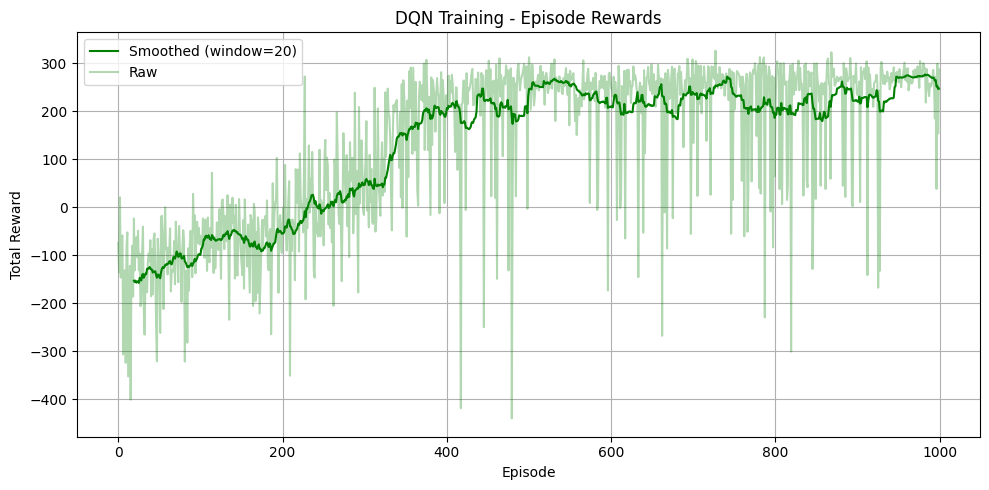

In [12]:
plot_metric(episode_rewards, title='DQN Training - Episode Rewards', ylabel='Total Reward', color='green', smoothed=True)

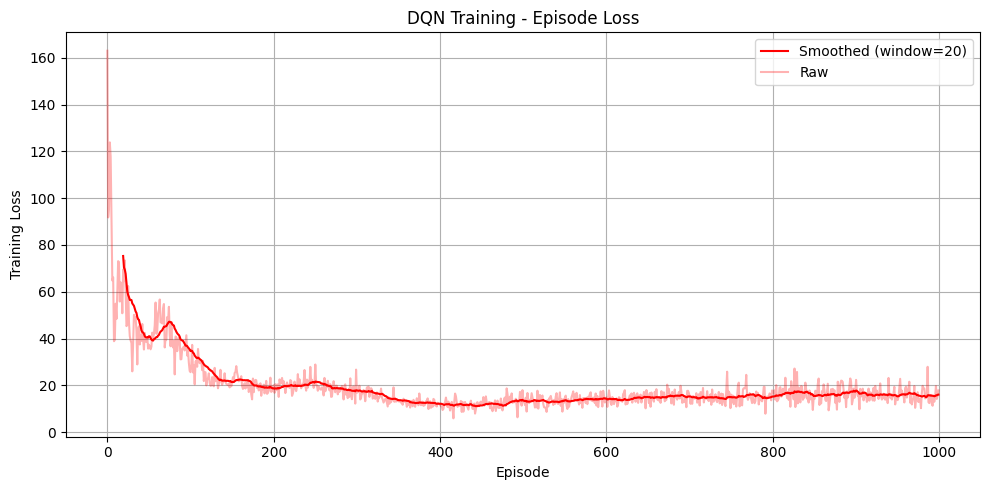

In [13]:
plot_metric(episode_losses, title='DQN Training - Episode Loss', ylabel='Training Loss', color='red', smoothed=True)

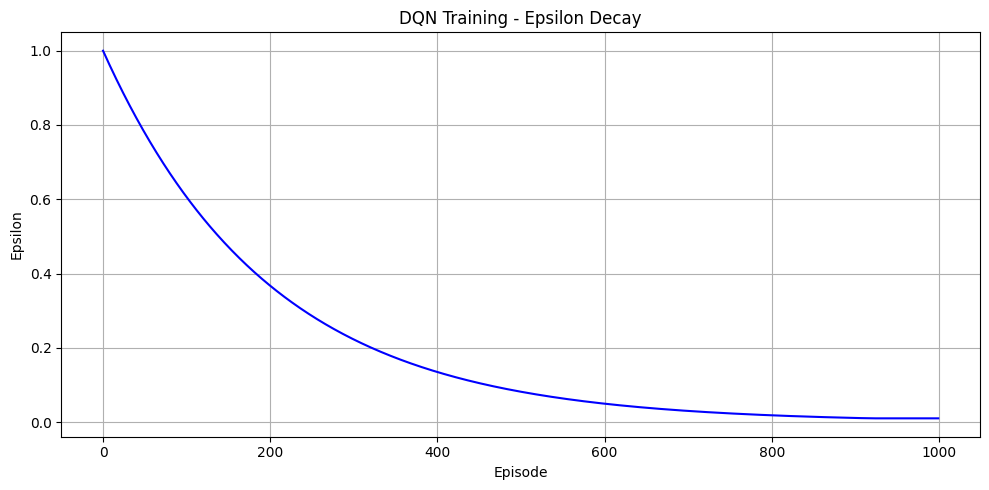

In [ ]:
plot_metric(episode_parameters, title='DQN Training - Epsilon Decay', ylabel='Epsilon', color='blue', smoothed=False)